In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 50.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a7475e248d69fdab9a913a13db45848e5e6b807c47bc8626d46f53b7a0d3c931
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


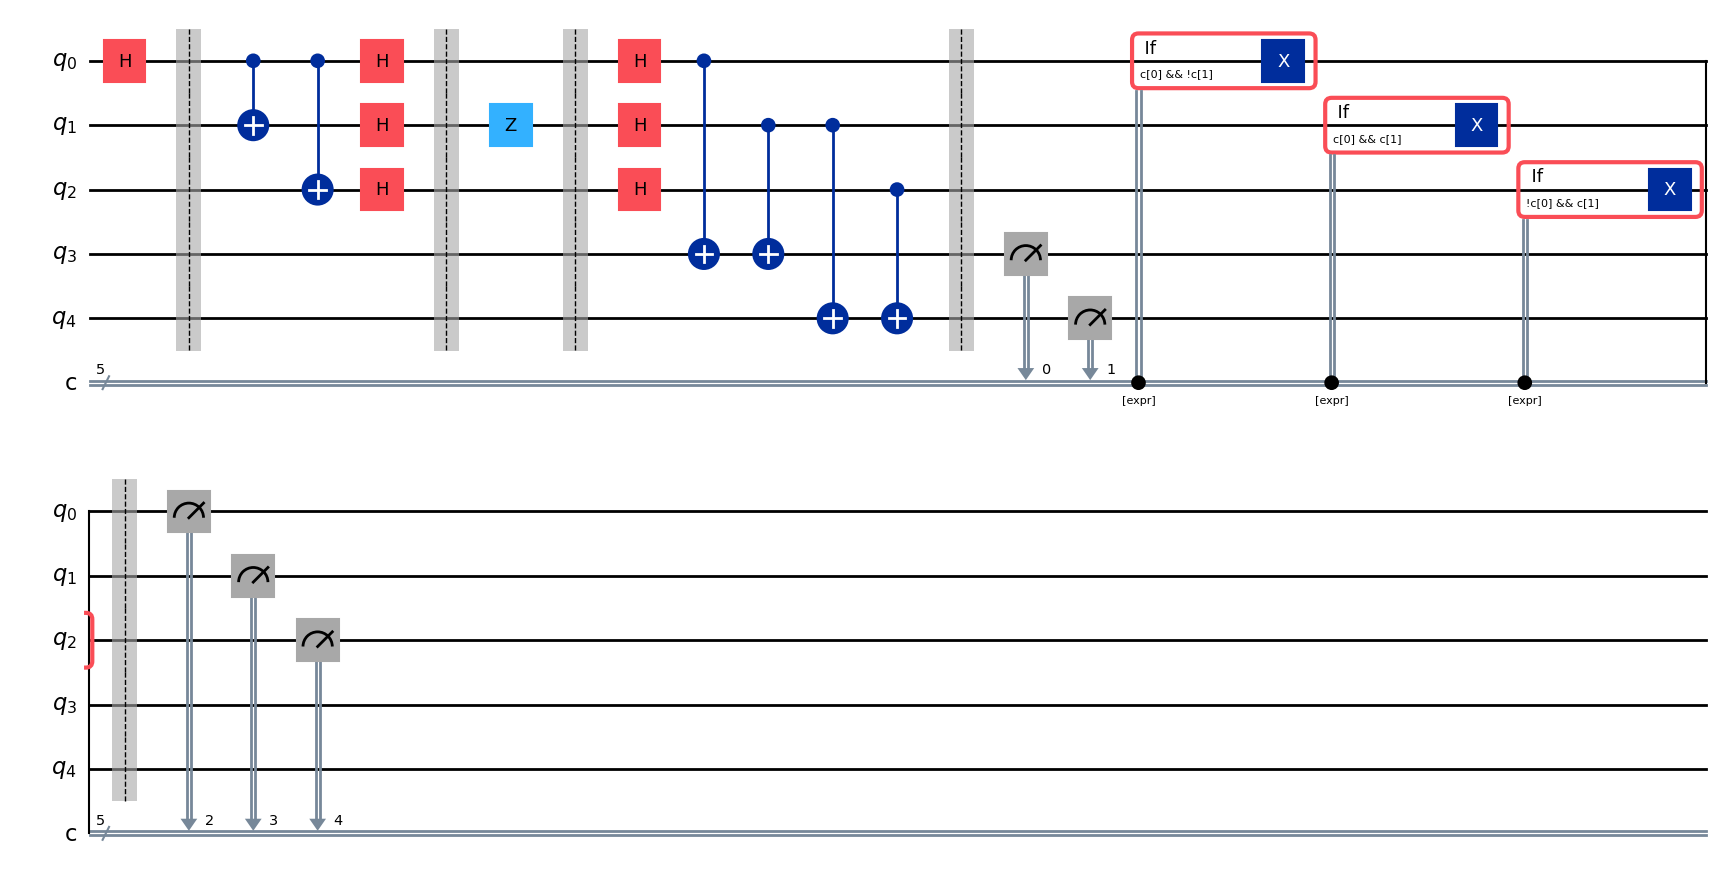

In [3]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.

flip = QuantumCircuit(5, 5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

flip.h(0)

flip.barrier()

# Encode into the phase basis:
# First CNOT-spread (same as bit-flip), then apply H to all three qubits.
# This maps |0> -> |+++> and |1> -> |--->
flip.cx(0, 1)
flip.cx(0, 2)
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# Add a phase-flip error on qubit 1.
# Z|+> = |-> and Z|-> = |+>
# Try errors on qubit 0 or 2. Try two simultaneous phase flips. Try a bit flip (X).
flip.z(1)

flip.barrier()

# Syndrome measurement:
# Apply H to convert the phase basis back to the computational basis.
# A phase flip (Z) in the |+/-> basis becomes a bit flip (X) in the |0/1> basis,
# so we can reuse the exact same CNOT syndrome circuit as the bit-flip code.
flip.h(0)
flip.h(1)
flip.h(2)

flip.cx(0, 3)
flip.cx(1, 3)
flip.cx(1, 4)
flip.cx(2, 4)

flip.barrier()

flip.measure([3, 4], [0, 1])

# Conditional corrections - same logic as the bit-flip code
# if c0 and not c1 then X(q0)
# if c0 and c1 then X(q1)
# if not c0 and c1 then X(q2)
with flip.if_test(expr.logic_and(flip.clbits[0], expr.logic_not(flip.clbits[1]))):
    flip.x(0)

with flip.if_test(expr.logic_and(flip.clbits[0], flip.clbits[1])):
    flip.x(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]), flip.clbits[1])):
    flip.x(2)

flip.barrier()

# The state is now back in the computational basis (alpha|000> + beta|111>).
# Measuring the three qubits gives the same statistics as the original qubit 0.
flip.measure([0, 1, 2], [2, 3, 4])

flip.draw("mpl")

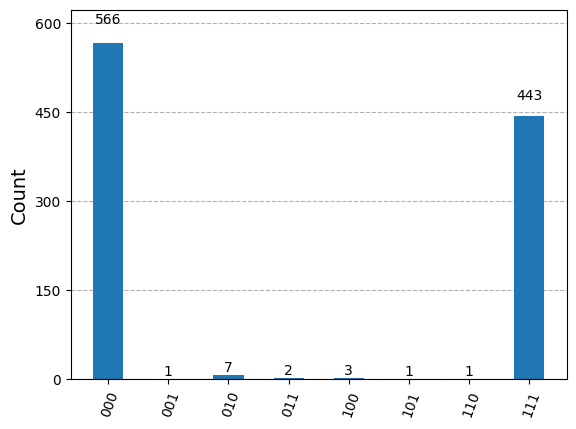

In [4]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)